# CKPT5: LangGraph-Orchestrated CLV Workflow


This notebook runs the **entire CLV pipeline** under a LangGraph StateGraph.

It includes:
- Data load + clean
- Multi-cutoff temporal splits
- Baselines (expanded set)
- Stacking (CKPT3)
- Extended features + baselines + stacking (CKPT4)
- Final report

A Gemini decision node determines whether to proceed to extended features; a deterministic fallback is used if Gemini is unavailable.


In [1]:
# Setup
import os
import sys
from dotenv import load_dotenv

# Ensure repo root is on path
sys.path.append('..')

load_dotenv()
print('GEMINI_API_KEY set:', bool(os.getenv('GEMINI_API_KEY')))


GEMINI_API_KEY set: True


In [2]:
# Import orchestrator
from src.react_agent import LangGraphCLVOrchestrator

agent = LangGraphCLVOrchestrator()


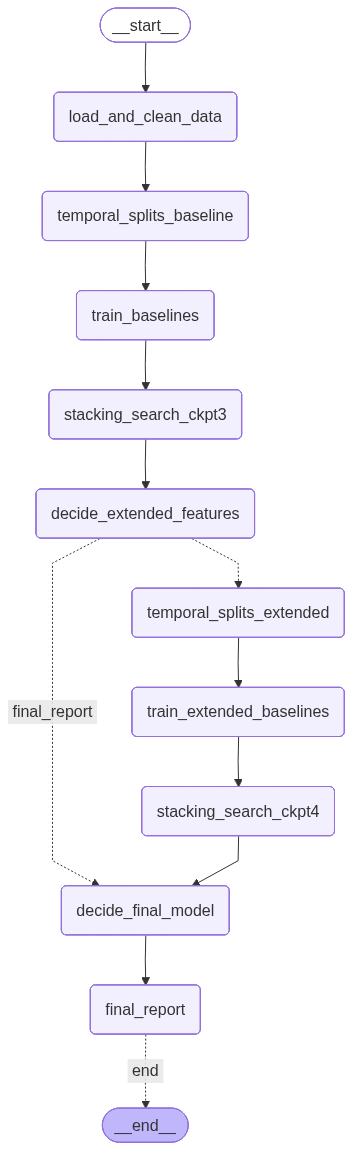

In [3]:
# Visualize graph (optional)
try:
    from IPython.display import display, Image
    g = agent.get_graph()
    try:
        display(Image(g.get_graph().draw_mermaid_png()))
    except Exception:
        print(g.get_graph().draw_mermaid())
except Exception as e:
    print('Graph visualization unavailable:', str(e))


In [4]:
# Run the LangGraph orchestrator
final_state = agent.run()

[Step complete] load_and_clean_data
[Step complete] temporal_splits_baseline
[Step complete] train_baselines
[Iteration 1/5] Trying EN_Config_A ...
[Iteration 1/5] EN_Config_A complete (Val MAE=0.8859)
[Iteration 2/5] Trying EN_Config_B ...
[Iteration 2/5] EN_Config_B complete (Val MAE=0.8771)
[Iteration 3/5] Trying RF_Config_B ...
[Iteration 3/5] RF_Config_B complete (Val MAE=0.9075)
[Iteration 4/5] Trying HGB_Config_B ...
[Iteration 4/5] HGB_Config_B complete (Val MAE=0.9169)
[Iteration 5/5] Trying XGB_Config_B ...
[Iteration 5/5] XGB_Config_B complete (Val MAE=0.9115)
[Step complete] stacking_search_ckpt3
[Step complete] decide_extended_features
[Step complete] temporal_splits_extended
[Step complete] train_extended_baselines
[Iteration 1/5] Trying EN_Config_A (extended) ...
[Iteration 1/5] EN_Config_A_ext complete (Val MAE=0.8820)
[Iteration 2/5] Trying EN_Config_B (extended) ...
[Iteration 2/5] EN_Config_B_ext complete (Val MAE=0.8859)
[Iteration 3/5] Trying RF_Config_B (extended)

In [5]:
# Report tables
report_tables = final_state.get('report_tables', {})
report_summary = final_state.get('report_summary', '')

for name, df in report_tables.items():
    print('===', name, '===')
    print(df.to_string(index=False))

print('Summary:')
print(report_summary)


=== ckpt2_baselines ===
       Model      MAE     RMSE
RandomForest 1.107570 1.973954
   SimpleAvg 1.111025 1.962446
     XGBoost 1.118455 1.850803
      HistGB 1.121183 2.219170
  ElasticNet 1.122049 2.160581
         MLP 1.157588 2.187911
  ExtraTrees 1.180362 2.058104
         SVR 1.208860 2.641942
     Poisson 1.221881 1.920366
         KNN 1.259693 2.618926
=== ckpt3_stacking ===
       Model      MAE     RMSE
 EN_Config_B 1.119712 2.140062
 RF_Config_B 1.137068 2.057463
XGB_Config_B 1.138895 1.925709
HGB_Config_B 1.143106 2.214394
 EN_Config_A 1.150015 2.222516
=== ckpt4_baselines ===
           Model      MAE     RMSE
   SimpleAvg_ext 1.103048 1.937503
RandomForest_ext 1.104301 1.948283
     XGBoost_ext 1.109614 1.833964
  ExtraTrees_ext 1.116255 1.935068
  ElasticNet_ext 1.119947 2.135041
      HistGB_ext 1.125045 2.199704
         SVR_ext 1.139583 2.686883
         MLP_ext 1.183311 2.173128
         KNN_ext 1.189503 2.553987
     Poisson_ext 1.452050 3.286222
=== ckpt4_stackin

## Notes
- The selection decision uses **validation MAE** only.
- Test metrics are computed only after selection for the final report.
